# R(2) NLTL scan fit

Fit the digitized NLTL R(2) scan with the retained opposite-parity OBE model.

The expensive fit parameters are the positive electric field `E_z` and the total beam power. The frequency offset is profiled cheaply, the vertical baseline is fixed to zero, and every simulated trace is normalized to the normal-parity peak.


## Setup

Conventions used below:

- The CSV x axis is IR MHz.
- The actual optical detuning uses the opposite sign and a factor of four: `delta_uv_MHz = -4 * (frequency_ir_MHz - ir_zero_MHz)`.
- The high-IR-frequency data peak is the normal-parity peak.
- The low-detuning simulated peak is the normal-parity peak.


In [1]:
from __future__ import annotations

import time
from dataclasses import dataclass
from functools import lru_cache
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import scipy.constants as cst
import scipy.optimize as opt
import scipy.signal as signal
import sympy as smp

from centrex_tlf import couplings, hamiltonian, lindblad, states, transitions
from centrex_tlf.lindblad.parameters import LindbladParameters
from centrex_tlf.lindblad.plan_static import prepare_lindblad_problem
from centrex_tlf.utils.rabi import (
    power_to_intensity_rectangular_beam,
    power_to_rabi_rectangular_beam,
)

plt.rcParams.update({"font.size": 14})

GAMMA = getattr(hamiltonian, "\u0393")
NOTEBOOK_DIR = Path.cwd()
CSV_PATH = NOTEBOOK_DIR / "digitized_det1_nltl_scan.csv"
if not CSV_PATH.exists():
    CSV_PATH = Path("examples/lindblad/digitized_det1_nltl_scan.csv")


In [2]:
transition = transitions.R2_F1_7o2_F3

B_FIELD = np.array([0.0, 0.0, 1e-5])  # G
BEAM_WX = 0.02  # m
BEAM_WY = 0.02  # m
VELOCITY = 184.0  # m/s
INTERACTION_LENGTH = 0.02  # m
T_END = INTERACTION_LENGTH / VELOCITY

INITIAL_F1 = 5 / 2
INITIAL_F = 2
INITIAL_MF = 0

TRANSVERSE_VELOCITY_SIGMA = 1.4  # m/s
OPTICAL_FREQUENCY_HZ = 1.1e15
OPTICAL_WAVELENGTH_M = cst.c / OPTICAL_FREQUENCY_HZ
DOPPLER_SIGMA_MHZ = OPTICAL_FREQUENCY_HZ * TRANSVERSE_VELOCITY_SIGMA / cst.c / 1e6

FIELD_SCAN_MHZ = np.linspace(150.0, 250.0, 101)  # V/cm
FIELD_REFERENCE_V_CM = 200.0
FIELD_BOUND_HALF_WIDTH_V_CM = 20.0

POWER_GRID_MW = np.linspace(20.0, 140.0, 13)
FIELD_GRID_POINTS = 9
IR_ZERO_GRID_HALF_WIDTH_MHZ = 5.0
IR_ZERO_GRID_POINTS = 101

FIT_DETUNING_STEP_MHZ = 1.0
FIT_SAVEAT = np.linspace(0.0, T_END, 201)
FIT_REL_TOL = 3e-7
FIT_ABS_TOL = 3e-9

FINAL_DETUNING_STEP_MHZ = 0.25
FINAL_SAVEAT = np.linspace(0.0, T_END, 801)
FINAL_REL_TOL = 1e-7
FINAL_ABS_TOL = 1e-9

DETUNING_PADDING_MHZ = 40.0
CONV_EDGE_PADDING_SIGMA = 6.0
SCAN_THREADS = None  # None lets the Rust backend choose.

NOMINAL_POWER_MW = 60.0
NOMINAL_E_FIELD_V_CM = 200.0

config = {
    "transition": transition.name,
    "beam_cm_by_cm": (BEAM_WX * 100, BEAM_WY * 100),
    "velocity_m_per_s": VELOCITY,
    "interaction_time_us": T_END * 1e6,
    "doppler_sigma_MHz": DOPPLER_SIGMA_MHZ,
    "field_scan_V_per_cm": (float(FIELD_SCAN_MHZ[0]), float(FIELD_SCAN_MHZ[-1])),
    "power_grid_mW": (float(POWER_GRID_MW[0]), float(POWER_GRID_MW[-1]), int(POWER_GRID_MW.size)),
    "fit_detuning_step_MHz": FIT_DETUNING_STEP_MHZ,
    "final_detuning_step_MHz": FINAL_DETUNING_STEP_MHZ,
}
config


{'transition': "R(2) F1'=7/2 F'=3",
 'beam_cm_by_cm': (2.0, 2.0),
 'velocity_m_per_s': 184.0,
 'interaction_time_us': 108.69565217391305,
 'doppler_sigma_MHz': 5.136887066051542,
 'field_scan_V_per_cm': (150.0, 250.0),
 'power_grid_mW': (20.0, 140.0, 13),
 'fit_detuning_step_MHz': 1.0,
 'final_detuning_step_MHz': 0.25}

## Load digitized scan and identify the data peaks

The higher-IR-frequency peak is the normal-parity feature. Peak centers are refined with a local quadratic fit so the separation estimate is not limited to the 1 MHz digitization grid.


In [3]:
data = np.genfromtxt(CSV_PATH, delimiter=",", names=True)
x_ir_MHz = np.asarray(data["frequency_MHz"], dtype=float)
y_data = np.asarray(data["y"], dtype=float)
sy_data = np.asarray(data["sy"], dtype=float)
sy_data = np.where(sy_data > 0, sy_data, np.nanmedian(sy_data[sy_data > 0]))


def quadratic_peak_center(
    x: np.ndarray, y: np.ndarray, idx: int, half_width: int = 2
) -> tuple[float, float]:
    lo = max(0, idx - half_width)
    hi = min(x.size, idx + half_width + 1)
    if hi - lo < 3:
        return float(x[idx]), float(y[idx])
    coeff = np.polyfit(x[lo:hi], y[lo:hi], deg=2)
    a, b, c = coeff
    if a >= 0:
        return float(x[idx]), float(y[idx])
    x0 = -b / (2 * a)
    if x0 < x[lo] or x0 > x[hi - 1]:
        return float(x[idx]), float(y[idx])
    y0 = np.polyval(coeff, x0)
    return float(x0), float(y0)


def find_two_data_peaks(x: np.ndarray, y: np.ndarray) -> dict[str, float]:
    prominence = max(0.1 * (np.nanmax(y) - np.nanmin(y)), np.nanmedian(sy_data))
    peaks, props = signal.find_peaks(y, distance=3, prominence=prominence)
    if peaks.size < 2:
        local = []
        for i in range(1, y.size - 1):
            if y[i] >= y[i - 1] and y[i] >= y[i + 1]:
                local.append(i)
        peaks = np.asarray(local, dtype=int)
    if peaks.size < 2:
        peaks = np.argsort(y)[-2:]
    strongest = peaks[np.argsort(y[peaks])[-2:]]
    low_idx, high_idx = sorted(strongest, key=lambda idx: x[idx])

    low_x, low_y = quadratic_peak_center(x, y, int(low_idx))
    high_x, high_y = quadratic_peak_center(x, y, int(high_idx))
    return {
        "opposite_ir_MHz": low_x,
        "opposite_y": low_y,
        "normal_ir_MHz": high_x,
        "normal_y": high_y,
        "separation_ir_MHz": high_x - low_x,
        "separation_uv_MHz": 4.0 * (high_x - low_x),
    }


data_peaks = find_two_data_peaks(x_ir_MHz, y_data)
data_peaks


{'opposite_ir_MHz': 1830.8143742252769,
 'opposite_y': 0.030311752807392622,
 'normal_ir_MHz': 1837.0751641560157,
 'normal_y': 0.051802076981402934,
 'separation_ir_MHz': 6.260789930738838,
 'separation_uv_MHz': 25.04315972295535}

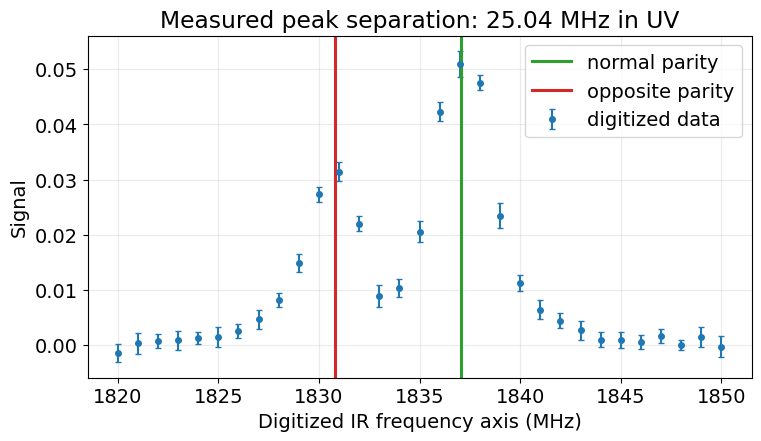

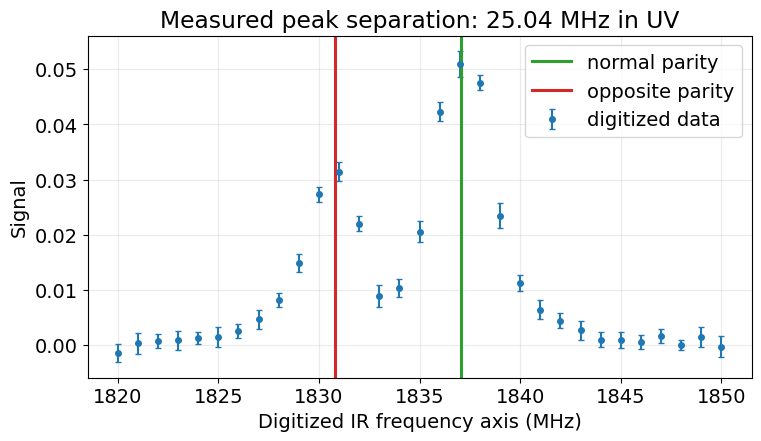

In [4]:
fig, ax = plt.subplots(figsize=(7.5, 4.3), constrained_layout=True)
ax.errorbar(x_ir_MHz, y_data, yerr=sy_data, fmt="o", ms=4, capsize=2, label="digitized data")
ax.axvline(data_peaks["normal_ir_MHz"], color="C2", lw=2.2, label="normal parity")
ax.axvline(data_peaks["opposite_ir_MHz"], color="C3", lw=2.2, label="opposite parity")
ax.set_xlabel("Digitized IR frequency axis (MHz)")
ax.set_ylabel("Signal")
ax.grid(alpha=0.25)
ax.legend()
ax.set_title(f"Measured peak separation: {data_peaks['separation_uv_MHz']:.2f} MHz in UV")
fig


## Hamiltonian-only field estimate

This scans positive electric field from 150 to 250 V/cm. The target states are identified at 200 V/cm by their largest bare component, then tracked across the scan by maximum overlap of the mixed-state vectors.


In [5]:
def state_label(state: states.CoupledState) -> str:
    qn = state.largest
    f1 = smp.S(str(qn.F1), rational=True) if qn.F1 is not None else None
    parity = "+" if qn.P == 1 else "-"
    return f"J={qn.J}, F1={f1}, F={qn.F}, mF={qn.mF}, P={parity}"


def b_f3_manifold_at_field(Ez_V_cm: float) -> hamiltonian.ReducedHamiltonian:
    selector = states.QuantumSelector(
        electronic=states.ElectronicState.B,
        J=transition.J_excited,
        F1=transition.F1_excited,
        F=transition.F_excited,
        P=[transition.P_excited, -transition.P_excited],
    )
    approx_states = list(states.generate_coupled_states_B(selector))
    return hamiltonian.generate_reduced_B_hamiltonian(
        approx_states,
        E=np.array([0.0, 0.0, Ez_V_cm]),
        B=B_FIELD,
        Jmin=transition.J_excited,
        Jmax=transition.J_excited + 2,
    )


def mixed_state_vectors(reduced: hamiltonian.ReducedHamiltonian) -> np.ndarray:
    return np.asarray([state.state_vector(reduced.QN_construct) for state in reduced.QN_basis])


def target_indices_at_reference(reduced: hamiltonian.ReducedHamiltonian) -> dict[str, list[int]]:
    targets = {"normal": [], "opposite": []}
    for idx, state in enumerate(reduced.QN_basis):
        qn = state.largest
        is_target = (
            qn.J == transition.J_excited
            and qn.F1 == transition.F1_excited
            and qn.F == transition.F_excited
            and abs(qn.mF) == 1
        )
        if not is_target:
            continue
        if qn.P == transition.P_excited:
            targets["normal"].append(idx)
        elif qn.P == -transition.P_excited:
            targets["opposite"].append(idx)
    if len(targets["normal"]) != 2 or len(targets["opposite"]) != 2:
        raise ValueError(
            f"Expected two normal and two opposite mF=+/-1 states at reference field; got {targets}"
        )
    return targets


def track_target_indices(
    field_values: np.ndarray,
    reference_field: float = FIELD_REFERENCE_V_CM,
) -> dict[str, np.ndarray | list[str]]:
    field_values = np.asarray(field_values, dtype=float)
    reference_pos = int(np.argmin(np.abs(field_values - reference_field)))
    reduced_by_field = [b_f3_manifold_at_field(float(Ez)) for Ez in field_values]
    vectors_by_field = [mixed_state_vectors(reduced) for reduced in reduced_by_field]

    reference_targets = target_indices_at_reference(reduced_by_field[reference_pos])
    tracked = {
        "normal": np.full((field_values.size, 2), -1, dtype=int),
        "opposite": np.full((field_values.size, 2), -1, dtype=int),
    }
    for role, indices in reference_targets.items():
        tracked[role][reference_pos] = np.asarray(indices, dtype=int)

    for direction in (-1, 1):
        if direction == -1:
            steps = range(reference_pos - 1, -1, -1)
            previous = reference_pos
        else:
            steps = range(reference_pos + 1, field_values.size)
            previous = reference_pos
        for i in steps:
            used: set[int] = set()
            for role in ("normal", "opposite"):
                new_indices = []
                for old_idx in tracked[role][previous]:
                    old_vec = vectors_by_field[previous][old_idx]
                    overlaps = np.abs(vectors_by_field[i] @ np.conjugate(old_vec))
                    for used_idx in used:
                        overlaps[used_idx] = -np.inf
                    new_idx = int(np.argmax(overlaps))
                    used.add(new_idx)
                    new_indices.append(new_idx)
                tracked[role][i] = new_indices
            previous = i

    normal_labels = [
        state_label(reduced_by_field[reference_pos].QN_basis[i])
        for i in tracked["normal"][reference_pos]
    ]
    opposite_labels = [
        state_label(reduced_by_field[reference_pos].QN_basis[i])
        for i in tracked["opposite"][reference_pos]
    ]
    return {
        "fields": field_values,
        "reduced": reduced_by_field,
        "tracked_normal": tracked["normal"],
        "tracked_opposite": tracked["opposite"],
        "reference_normal_labels": normal_labels,
        "reference_opposite_labels": opposite_labels,
    }


def tracked_separation_curve(field_values: np.ndarray) -> dict[str, np.ndarray | object]:
    tracked = track_target_indices(field_values)
    separations = []
    normal_centers = []
    opposite_centers = []
    for i, reduced in enumerate(tracked["reduced"]):
        normal = tracked["tracked_normal"][i]
        opposite = tracked["tracked_opposite"][i]
        normal_energy = np.mean([np.real(reduced.H[idx, idx]) for idx in normal])
        opposite_energy = np.mean([np.real(reduced.H[idx, idx]) for idx in opposite])
        normal_mhz = normal_energy / (2 * np.pi * 1e6)
        opposite_mhz = opposite_energy / (2 * np.pi * 1e6)
        normal_centers.append(normal_mhz)
        opposite_centers.append(opposite_mhz)
        separations.append(abs(opposite_mhz - normal_mhz))
    tracked["normal_center_MHz"] = np.asarray(normal_centers)
    tracked["opposite_center_MHz"] = np.asarray(opposite_centers)
    tracked["separation_MHz"] = np.asarray(separations)
    return tracked


start = time.perf_counter()
field_curve = tracked_separation_curve(FIELD_SCAN_MHZ)
field_timing_seconds = time.perf_counter() - start

sep = np.asarray(field_curve["separation_MHz"])
fields = np.asarray(field_curve["fields"])
target_sep = data_peaks["separation_uv_MHz"]
order = np.argsort(sep)
if target_sep < sep[order][0] or target_sep > sep[order][-1]:
    nearest = int(np.argmin(np.abs(sep - target_sep)))
    E_est_V_cm = float(fields[nearest])
    field_estimate_note = "target separation outside scanned range; using nearest field"
else:
    E_est_V_cm = float(np.interp(target_sep, sep[order], fields[order]))
    field_estimate_note = "interpolated from separation curve"

E_FIT_BOUNDS = (
    max(1.0, E_est_V_cm - FIELD_BOUND_HALF_WIDTH_V_CM),
    min(250.0, E_est_V_cm + FIELD_BOUND_HALF_WIDTH_V_CM),
)

field_estimate = {
    "data_separation_uv_MHz": float(target_sep),
    "E_est_V_cm": E_est_V_cm,
    "E_fit_bounds_V_cm": E_FIT_BOUNDS,
    "timing_seconds": field_timing_seconds,
    "note": field_estimate_note,
    "reference_normal_labels": field_curve["reference_normal_labels"],
    "reference_opposite_labels": field_curve["reference_opposite_labels"],
}
field_estimate


C:\Users\ogras\Documents\GitHub\CeNTREX-TlF\centrex_tlf\states\find_states.py:564: UserWarning: Low overlap detected for approximate states at indices [0, 1, 12, 13]. Overlaps: [0.49989300452802643, 0.499820652401043, 0.49989300445863893, 0.4998206524122943]. The approximate states may not be well-represented in the eigenstate basis.
  indices = find_exact_states_indices(
C:\Users\ogras\Documents\GitHub\CeNTREX-TlF\centrex_tlf\states\find_states.py:564: UserWarning: Low overlap detected for approximate states at indices [0, 1, 12, 13]. Overlaps: [0.4996555150141492, 0.4995806753346004, 0.4996555149435151, 0.49958067534515405]. The approximate states may not be well-represented in the eigenstate basis.
  indices = find_exact_states_indices(
C:\Users\ogras\Documents\GitHub\CeNTREX-TlF\centrex_tlf\states\find_states.py:564: UserWarning: Low overlap detected for approximate states at indices [0, 1, 12, 13]. Overlaps: [0.49942110446415056, 0.4993437716300934, 0.49942110439504045, 0.49934377

{'data_separation_uv_MHz': 25.04315972295535,
 'E_est_V_cm': 171.60757571046202,
 'E_fit_bounds_V_cm': (151.60757571046202, 191.60757571046202),
 'timing_seconds': 98.41506749996915,
 'note': 'interpolated from separation curve',
 'reference_normal_labels': ['J=3, F1=7/2, F=3, mF=-1, P=-',
  'J=3, F1=7/2, F=3, mF=1, P=-'],
 'reference_opposite_labels': ['J=3, F1=7/2, F=3, mF=-1, P=+',
  'J=3, F1=7/2, F=3, mF=1, P=+']}

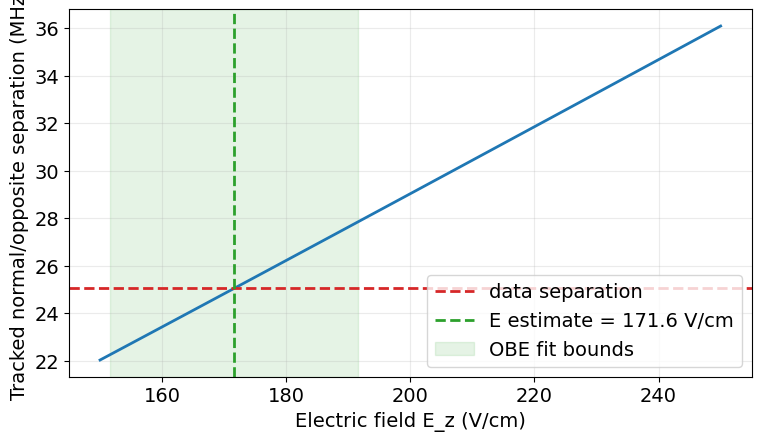

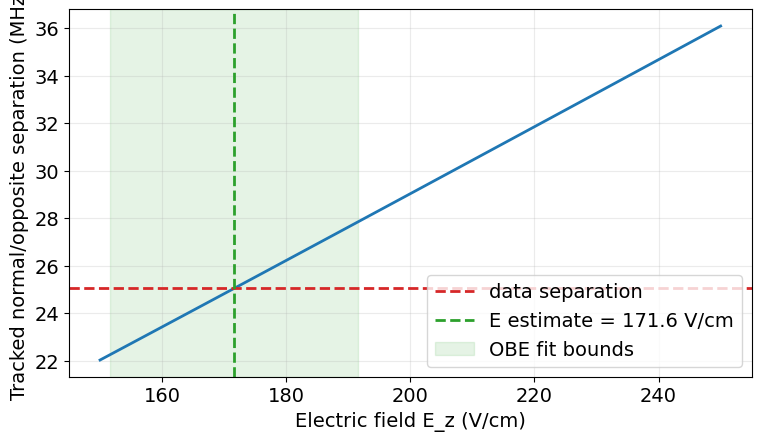

In [6]:
fig, ax = plt.subplots(figsize=(7.5, 4.3), constrained_layout=True)
ax.plot(field_curve["fields"], field_curve["separation_MHz"], lw=2)
ax.axhline(data_peaks["separation_uv_MHz"], color="C3", ls="--", lw=2, label="data separation")
ax.axvline(E_est_V_cm, color="C2", ls="--", lw=2, label=f"E estimate = {E_est_V_cm:.1f} V/cm")
ax.axvspan(E_FIT_BOUNDS[0], E_FIT_BOUNDS[1], color="C2", alpha=0.12, label="OBE fit bounds")
ax.set_xlabel("Electric field E_z (V/cm)")
ax.set_ylabel("Tracked normal/opposite separation (MHz)")
ax.grid(alpha=0.25)
ax.legend()
fig


## OBE model builder

For a fixed electric field the system and Rust plan are cached. All optical coupling symbols are bound to one shared runtime `rabi` parameter, so power changes do not require rebuilding the system.


In [7]:
ground_main = 1 * next(
    iter(
        states.generate_coupled_states_X(
            states.QuantumSelector(
                electronic=states.ElectronicState.X,
                J=transition.J_ground,
                F1=INITIAL_F1,
                F=INITIAL_F,
                mF=INITIAL_MF,
                P=transition.P_ground,
            )
        )
    )
)
excited_main = 1 * next(
    iter(
        states.generate_coupled_states_B(
            states.QuantumSelector(
                electronic=states.ElectronicState.B,
                J=transition.J_excited,
                F1=transition.F1_excited,
                F=transition.F_excited,
                mF=1,
                P=transition.P_excited,
            )
        )
    )
)

transition_selectors = couplings.generate_transition_selectors(
    transitions=[transition],
    polarizations=[[couplings.polarization_X]],
    ground_mains=[ground_main],
    excited_mains=[excited_main],
)

RABI_PARAMETER_NAME = "rabi"
DETUNING_PARAMETER_NAME = "detuning"


def initial_state_index(system: lindblad.OBESystem) -> int:
    candidates = []
    for idx, state in enumerate(system.QN):
        qn = state.largest
        if (
            qn.electronic_state == states.ElectronicState.X
            and qn.J == transition.J_ground
            and qn.F1 == INITIAL_F1
            and qn.F == INITIAL_F
            and qn.mF == INITIAL_MF
        ):
            candidates.append(idx)
    if not candidates:
        raise ValueError("Could not find the requested initial X level.")
    return min(candidates, key=lambda idx: float(np.real(system.H_int[idx, idx])))


def initial_density_matrix(system: lindblad.OBESystem) -> np.ndarray:
    rho0 = np.zeros((len(system.QN), len(system.QN)), dtype=np.complex128)
    rho0[initial_state_index(system), initial_state_index(system)] = 1.0
    return rho0


def excited_indices(system: lindblad.OBESystem) -> list[int]:
    return [
        idx
        for idx, state in enumerate(system.QN)
        if state.largest.electronic_state == states.ElectronicState.B
    ]


def parameter_values(system: lindblad.OBESystem) -> LindbladParameters:
    params = LindbladParameters()
    rabi = params.real(RABI_PARAMETER_NAME, 0.0)
    detuning = params.real(DETUNING_PARAMETER_NAME, 0.0)

    for symbol in system.H_symbolic.free_symbols:
        name = str(symbol)
        if symbol in system.coupling_symbols:
            params.bind(symbol, rabi, finalize=False)
        elif name == str(getattr(transition_selectors[0], "\u03b4")):
            params.bind(symbol, detuning, finalize=False)
        else:
            params.real(name, 0.0)

    for symbol_group in system.polarization_symbols:
        symbols = symbol_group if isinstance(symbol_group, (list, tuple)) else [symbol_group]
        for symbol in symbols:
            params.bind(symbol, 1.0, finalize=False)

    params._finalize()
    return params


def rabi_rate_for_power(system: lindblad.OBESystem, power_mW: float) -> float:
    main_coupling = abs(system.couplings[0].main_coupling)
    return power_to_rabi_rectangular_beam(
        power_mW * 1e-3,
        main_coupling,
        BEAM_WX,
        BEAM_WY,
    )


@dataclass(frozen=True)
class PreparedFitModel:
    Ez_V_cm: float
    system: lindblad.OBESystem
    params: LindbladParameters
    prepared: object
    rho0: np.ndarray
    photon_integral_weights: list[tuple[int, float]]


@lru_cache(maxsize=32)
def build_fit_model(Ez_rounded_V_cm: float, compact: bool = True) -> PreparedFitModel:
    Ez_V_cm = float(Ez_rounded_V_cm)
    system = lindblad.generate_OBE_system_transitions(
        [transition],
        transition_selectors,
        qn_compact=True if compact else None,
        E=np.array([0.0, 0.0, Ez_V_cm]),
        B=B_FIELD,
        retain_opposite_parity_levels=True,
        method="matrix",
    )
    params = parameter_values(system)
    prepared = prepare_lindblad_problem(
        system,
        params,
        backend="rust",
        hamiltonian_representation="decomposed",
    )
    weights = [(int(idx), float(GAMMA)) for idx in excited_indices(system)]
    return PreparedFitModel(
        Ez_V_cm=Ez_V_cm,
        system=system,
        params=params,
        prepared=prepared,
        rho0=initial_density_matrix(system),
        photon_integral_weights=weights,
    )


def rounded_field(Ez_V_cm: float) -> float:
    return round(float(Ez_V_cm), 3)


In [8]:
nominal_model = build_fit_model(rounded_field(NOMINAL_E_FIELD_V_CM), compact=True)
{
    "levels_compact": len(nominal_model.system.QN),
    "excited_levels": len(excited_indices(nominal_model.system)),
    "nominal_rabi_MHz": rabi_rate_for_power(nominal_model.system, NOMINAL_POWER_MW)
    / (2 * np.pi * 1e6),
    "nominal_intensity_mW_per_cm2": power_to_intensity_rectangular_beam(
        NOMINAL_POWER_MW * 1e-3, BEAM_WX, BEAM_WY
    )
    * 0.1,
}


C:\Users\ogras\Documents\GitHub\CeNTREX-TlF\centrex_tlf\states\find_states.py:564: UserWarning: Low overlap detected for approximate states at indices [0, 1, 12, 13]. Overlaps: [0.49174457879912414, 0.49163644217435554, 0.49174457871440175, 0.49163644220088737]. The approximate states may not be well-represented in the eigenstate basis.
  indices = find_exact_states_indices(
C:\Users\ogras\Documents\GitHub\CeNTREX-TlF\centrex_tlf\states\find_states.py:564: UserWarning: Low overlap detected for approximate states at indices [8, 10]. Overlaps: [0.43344884338308637, 0.4334488177466614]. The approximate states may not be well-represented in the eigenstate basis.
  indices = find_exact_states_indices(


{'levels_compact': 38,
 'excited_levels': 14,
 'nominal_rabi_MHz': np.float64(0.30622782552328554),
 'nominal_intensity_mW_per_cm2': 15.0}

## Fast scan utilities

The fit solves a zero-transverse-velocity scan on a uniform UV detuning grid, then applies the transverse Doppler distribution by convolution.


In [9]:
def detuning_grid_for_ir_zero(
    ir_zero_MHz: float,
    step_MHz: float,
    *,
    padding_MHz: float = DETUNING_PADDING_MHZ,
) -> np.ndarray:
    mapped = -4.0 * (x_ir_MHz - ir_zero_MHz)
    lo = mapped.min() - padding_MHz - CONV_EDGE_PADDING_SIGMA * DOPPLER_SIGMA_MHZ
    hi = mapped.max() + padding_MHz + CONV_EDGE_PADDING_SIGMA * DOPPLER_SIGMA_MHZ
    return np.arange(lo, hi + 0.5 * step_MHz, step_MHz)


def gaussian_convolve_uniform_grid(
    x: np.ndarray,
    y: np.ndarray,
    sigma: float,
    truncate_sigma: float = 6.0,
) -> np.ndarray:
    dx = float(np.mean(np.diff(x)))
    if not np.allclose(np.diff(x), dx):
        raise ValueError("x must be uniformly spaced for convolution")
    half_width = int(np.ceil(truncate_sigma * sigma / dx))
    offsets = dx * np.arange(-half_width, half_width + 1)
    kernel = np.exp(-0.5 * (offsets / sigma) ** 2)
    kernel /= kernel.sum()
    if y.ndim == 1:
        return np.convolve(y, kernel, mode="same")
    return np.apply_along_axis(lambda col: np.convolve(col, kernel, mode="same"), axis=0, arr=y)


def photon_count_scan_for_powers(
    model: PreparedFitModel,
    detuning_MHz: np.ndarray,
    power_mW: np.ndarray,
    *,
    saveat: np.ndarray,
    reltol: float,
    abstol: float,
    threads: int | None = SCAN_THREADS,
) -> dict[str, object]:
    power_mW = np.asarray(power_mW, dtype=float)
    rabi_values = np.asarray([rabi_rate_for_power(model.system, p) for p in power_mW])
    result = lindblad.grid_scan(
        model.prepared,
        model.rho0,
        (0.0, T_END),
        scan={
            DETUNING_PARAMETER_NAME: 2 * np.pi * 1e6 * np.asarray(detuning_MHz, dtype=float),
            RABI_PARAMETER_NAME: rabi_values,
        },
        solver="dopri5",
        execution_mode="expanded_sparse",
        output="photon_integral",
        output_when="final",
        integral_weights=model.photon_integral_weights,
        saveat=None,
        dt=2e-9,
        reltol=reltol,
        abstol=abstol,
        parallel=True,
        threads=threads,
        collect_stats=True,
    )
    photons = result.values.reshape(detuning_MHz.size, power_mW.size, -1)[:, :, -1]
    return {
        "detuning_MHz": np.asarray(detuning_MHz, dtype=float),
        "power_mW": power_mW,
        "rabi_values": rabi_values,
        "photons": photons,
        "result": result,
    }


def convolved_scan_for_powers(
    model: PreparedFitModel,
    detuning_MHz: np.ndarray,
    power_mW: np.ndarray,
    *,
    saveat: np.ndarray,
    reltol: float,
    abstol: float,
) -> dict[str, object]:
    scan = photon_count_scan_for_powers(
        model,
        detuning_MHz,
        power_mW,
        saveat=None,
        reltol=reltol,
        abstol=abstol,
    )
    scan["doppler_photons"] = gaussian_convolve_uniform_grid(
        scan["detuning_MHz"],
        scan["photons"],
        DOPPLER_SIGMA_MHZ,
    )
    return scan


## Compact-system validation

Run this cell once before a long fit. It compares compact and full retained-opposite-parity systems at nominal settings on a sparse grid.


In [10]:
VALIDATION_DETUNING_MHZ = np.arange(-40.0, 81.0, 4.0)
validation_start = time.perf_counter()
validation_compact = build_fit_model(rounded_field(NOMINAL_E_FIELD_V_CM), compact=True)
validation_full = build_fit_model(rounded_field(NOMINAL_E_FIELD_V_CM), compact=False)

scan_compact = convolved_scan_for_powers(
    validation_compact,
    VALIDATION_DETUNING_MHZ,
    np.array([NOMINAL_POWER_MW]),
    saveat=FIT_SAVEAT,
    reltol=FIT_REL_TOL,
    abstol=FIT_ABS_TOL,
)
scan_full = convolved_scan_for_powers(
    validation_full,
    VALIDATION_DETUNING_MHZ,
    np.array([NOMINAL_POWER_MW]),
    saveat=FIT_SAVEAT,
    reltol=FIT_REL_TOL,
    abstol=FIT_ABS_TOL,
)
validation_seconds = time.perf_counter() - validation_start

yc = scan_compact["doppler_photons"][:, 0]
yf = scan_full["doppler_photons"][:, 0]
yc_norm = yc / np.nanmax(yc)
yf_norm = yf / np.nanmax(yf)
validation_summary = {
    "compact_levels": len(validation_compact.system.QN),
    "full_levels": len(validation_full.system.QN),
    "compact_peak_MHz": float(VALIDATION_DETUNING_MHZ[np.argmax(yc)]),
    "full_peak_MHz": float(VALIDATION_DETUNING_MHZ[np.argmax(yf)]),
    "max_abs_normalized_difference": float(np.nanmax(np.abs(yc_norm - yf_norm))),
    "timing_seconds": validation_seconds,
}
validation_summary


C:\Users\ogras\Documents\GitHub\CeNTREX-TlF\centrex_tlf\states\find_states.py:564: UserWarning: Low overlap detected for approximate states at indices [0, 1, 12, 13]. Overlaps: [0.49174457879912414, 0.49163644217435554, 0.49174457871440175, 0.49163644220088737]. The approximate states may not be well-represented in the eigenstate basis.
  indices = find_exact_states_indices(
C:\Users\ogras\Documents\GitHub\CeNTREX-TlF\centrex_tlf\states\find_states.py:564: UserWarning: Low overlap detected for approximate states at indices [8, 10]. Overlaps: [0.43344884338308637, 0.4334488177466614]. The approximate states may not be well-represented in the eigenstate basis.
  indices = find_exact_states_indices(


{'compact_levels': 38,
 'full_levels': 154,
 'compact_peak_MHz': 0.0,
 'full_peak_MHz': 0.0,
 'max_abs_normalized_difference': 1.502395684527258e-07,
 'timing_seconds': 108.22180769999977}

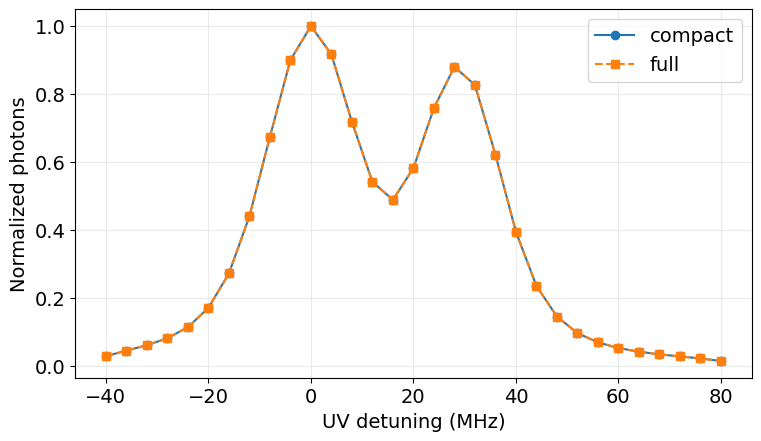

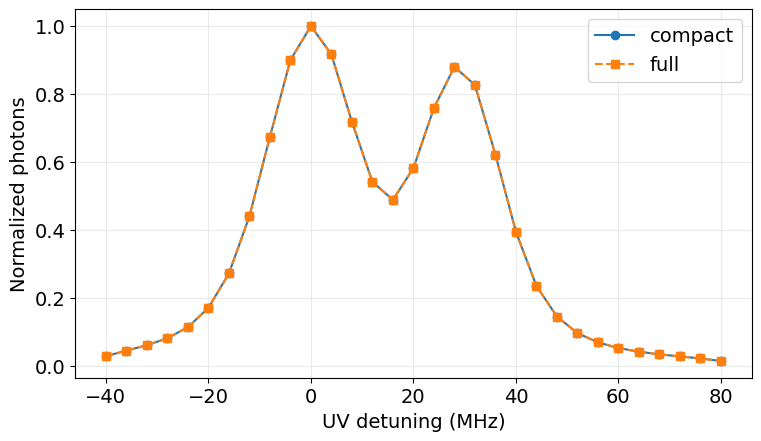

In [ ]:
fig, ax = plt.subplots(figsize=(7.5, 4.3), constrained_layout=True)
ax.plot(VALIDATION_DETUNING_MHZ, yc_norm, "o-", label="compact")
ax.plot(VALIDATION_DETUNING_MHZ, yf_norm, "s--", label="full")
ax.set_xlabel("UV detuning (MHz)")
ax.set_ylabel("Normalized photons")
ax.grid(alpha=0.25)
ax.legend()


## Fit objective

For each expensive `(E_z, power)` pair, `ir_zero_MHz` is profiled on a cheap one-dimensional grid. The simulation is normalized to its lower-detuning peak, and the data are normalized to the high-IR normal-parity peak.


In [12]:
def simulated_normal_peak(detuning_MHz: np.ndarray, photons: np.ndarray) -> tuple[float, float]:
    peaks, props = signal.find_peaks(
        photons, prominence=0.05 * (np.nanmax(photons) - np.nanmin(photons))
    )
    if peaks.size >= 2:
        strongest = peaks[np.argsort(photons[peaks])[-2:]]
        idx = int(strongest[np.argmin(detuning_MHz[strongest])])
        return float(detuning_MHz[idx]), float(photons[idx])
    if peaks.size == 1:
        idx = int(peaks[0])
        return float(detuning_MHz[idx]), float(photons[idx])
    idx = int(np.argmax(photons))
    return float(detuning_MHz[idx]), float(photons[idx])


def chi2_for_offset(
    detuning_MHz: np.ndarray,
    photons: np.ndarray,
    ir_zero_MHz: float,
) -> dict[str, float | np.ndarray]:
    sim_normal_delta, sim_peak = simulated_normal_peak(detuning_MHz, photons)
    if sim_peak <= 0:
        return {"chi2": np.inf, "scale": np.nan, "sim_normal_delta_MHz": sim_normal_delta}

    data_delta_uv = -4.0 * (x_ir_MHz - ir_zero_MHz)
    model_raw = np.interp(data_delta_uv, detuning_MHz, photons, left=np.nan, right=np.nan)
    valid = np.isfinite(model_raw)
    if np.count_nonzero(valid) < 0.8 * x_ir_MHz.size:
        return {"chi2": np.inf, "scale": np.nan, "sim_normal_delta_MHz": sim_normal_delta}

    scale = data_peaks["normal_y"] / sim_peak
    model_y = scale * model_raw
    residual = (y_data[valid] - model_y[valid]) / sy_data[valid]
    chi2 = float(np.sum(residual**2))
    return {
        "chi2": chi2,
        "scale": float(scale),
        "sim_normal_delta_MHz": sim_normal_delta,
        "model_y": model_y,
        "data_delta_uv": data_delta_uv,
    }


def profile_ir_zero(
    detuning_MHz: np.ndarray,
    photons: np.ndarray,
    ir_zero_guess_MHz: float,
    *,
    half_width_MHz: float = IR_ZERO_GRID_HALF_WIDTH_MHZ,
    points: int = IR_ZERO_GRID_POINTS,
) -> dict[str, object]:
    offsets = np.linspace(
        ir_zero_guess_MHz - half_width_MHz, ir_zero_guess_MHz + half_width_MHz, points
    )
    rows = [chi2_for_offset(detuning_MHz, photons, offset) for offset in offsets]
    chi2 = np.asarray([row["chi2"] for row in rows], dtype=float)
    best_idx = int(np.nanargmin(chi2))
    best = dict(rows[best_idx])
    best["ir_zero_MHz"] = float(offsets[best_idx])
    best["offset_grid_MHz"] = offsets
    best["chi2_grid"] = chi2
    return best


def evaluate_field_power_grid(
    field_grid_V_cm: np.ndarray,
    power_grid_mW: np.ndarray,
    *,
    step_MHz: float = FIT_DETUNING_STEP_MHZ,
    saveat: np.ndarray = FIT_SAVEAT,
    reltol: float = FIT_REL_TOL,
    abstol: float = FIT_ABS_TOL,
) -> dict[str, object]:
    start = time.perf_counter()
    normal_sim_guess_MHz = 0.0
    ir_zero_guess_MHz = data_peaks["normal_ir_MHz"] + normal_sim_guess_MHz / 4.0
    detuning_MHz = detuning_grid_for_ir_zero(ir_zero_guess_MHz, step_MHz)

    rows = []
    scans = {}
    for Ez in field_grid_V_cm:
        model = build_fit_model(rounded_field(Ez), compact=True)
        scan = convolved_scan_for_powers(
            model,
            detuning_MHz,
            power_grid_mW,
            saveat=saveat,
            reltol=reltol,
            abstol=abstol,
        )
        scans[rounded_field(Ez)] = scan
        for j, power in enumerate(power_grid_mW):
            profiled = profile_ir_zero(
                scan["detuning_MHz"],
                scan["doppler_photons"][:, j],
                ir_zero_guess_MHz,
            )
            rows.append(
                {
                    "Ez_V_cm": float(Ez),
                    "power_mW": float(power),
                    "chi2": float(profiled["chi2"]),
                    "ir_zero_MHz": float(profiled["ir_zero_MHz"]),
                    "scale": float(profiled["scale"]),
                    "sim_normal_delta_MHz": float(profiled["sim_normal_delta_MHz"]),
                }
            )
    elapsed = time.perf_counter() - start
    return {
        "rows": rows,
        "scans": scans,
        "field_grid_V_cm": np.asarray(field_grid_V_cm, dtype=float),
        "power_grid_mW": np.asarray(power_grid_mW, dtype=float),
        "detuning_MHz": detuning_MHz,
        "elapsed_seconds": elapsed,
    }


## Coarse OBE fit

This is the first expensive cell. It scans a compact grid over the field range inferred from peak separation and the configured power range.


In [13]:
FIELD_GRID_V_CM = np.linspace(E_FIT_BOUNDS[0], E_FIT_BOUNDS[1], FIELD_GRID_POINTS)

coarse_fit = evaluate_field_power_grid(FIELD_GRID_V_CM, POWER_GRID_MW)
coarse_rows = coarse_fit["rows"]
best_coarse = min(coarse_rows, key=lambda row: row["chi2"])
print(f"Coarse fit solver time: {coarse_fit['elapsed_seconds']:.1f} s")
best_coarse


C:\Users\ogras\Documents\GitHub\CeNTREX-TlF\centrex_tlf\states\find_states.py:564: UserWarning: Low overlap detected for approximate states at indices [0, 1, 12, 13]. Overlaps: [0.4993822679335401, 0.4993663941484324, 0.4993822678447086, 0.4993663941462886]. The approximate states may not be well-represented in the eigenstate basis.
  indices = find_exact_states_indices(
C:\Users\ogras\Documents\GitHub\CeNTREX-TlF\centrex_tlf\states\find_states.py:564: UserWarning: Low overlap detected for approximate states at indices [0, 1, 12, 13]. Overlaps: [0.49829704022143473, 0.4982712742645884, 0.49829704013316145, 0.49827127426582946]. The approximate states may not be well-represented in the eigenstate basis.
  indices = find_exact_states_indices(
C:\Users\ogras\Documents\GitHub\CeNTREX-TlF\centrex_tlf\states\find_states.py:564: UserWarning: Low overlap detected for approximate states at indices [0, 1, 12, 13]. Overlaps: [0.4972758890422983, 0.4972400588403774, 0.49727588895558, 0.49724005884

Coarse fit solver time: 7692.2 s


{'Ez_V_cm': 176.60757571046202,
 'power_mW': 20.0,
 'chi2': 420.7794434226838,
 'ir_zero_MHz': 1837.1751641560156,
 'scale': 0.06838383348993377,
 'sim_normal_delta_MHz': 0.47933422775361123}

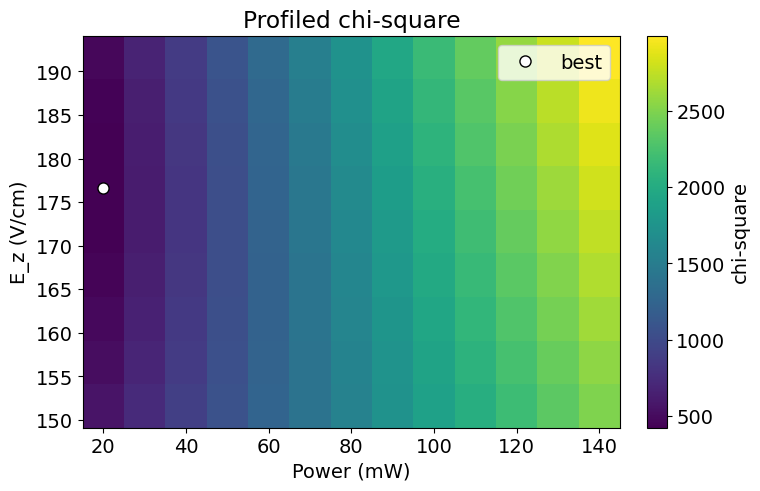

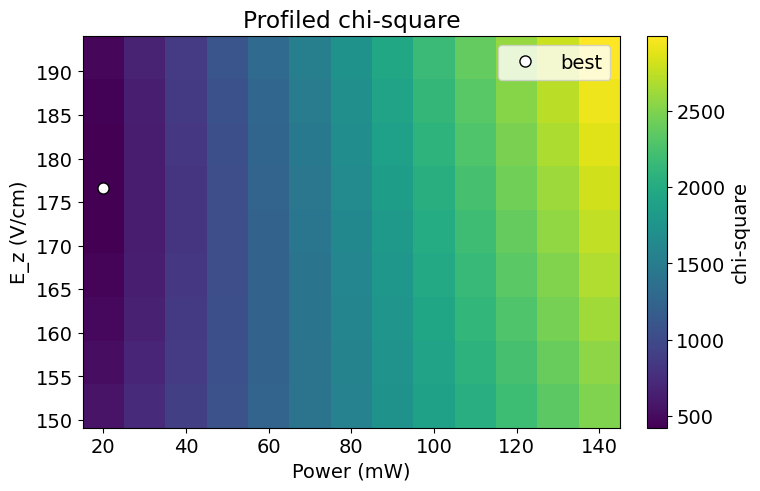

In [ ]:
chi2_grid = np.full((FIELD_GRID_V_CM.size, POWER_GRID_MW.size), np.nan)
for row in coarse_rows:
    i = int(np.argmin(np.abs(FIELD_GRID_V_CM - row["Ez_V_cm"])))
    j = int(np.argmin(np.abs(POWER_GRID_MW - row["power_mW"])))
    chi2_grid[i, j] = row["chi2"]

fig, ax = plt.subplots(figsize=(7.5, 4.8), constrained_layout=True)
mesh = ax.pcolormesh(POWER_GRID_MW, FIELD_GRID_V_CM, chi2_grid, shading="auto")
ax.plot(best_coarse["power_mW"], best_coarse["Ez_V_cm"], "wo", mec="k", ms=8, label="best")
ax.set_xlabel("Power (mW)")
ax.set_ylabel("E_z (V/cm)")
ax.set_title("Profiled chi-square")
fig.colorbar(mesh, ax=ax, label="chi-square")
ax.legend()


## Final best-fit trace

The best coarse-grid point is recomputed on the final detuning grid. If needed, tighten the grids above and rerun from the coarse-fit section.


In [15]:
final_start = time.perf_counter()
final_model = build_fit_model(rounded_field(best_coarse["Ez_V_cm"]), compact=True)
final_ir_zero_guess = best_coarse["ir_zero_MHz"]
final_detuning_MHz = detuning_grid_for_ir_zero(final_ir_zero_guess, FINAL_DETUNING_STEP_MHZ)
final_scan = convolved_scan_for_powers(
    final_model,
    final_detuning_MHz,
    np.array([best_coarse["power_mW"]]),
    saveat=FINAL_SAVEAT,
    reltol=FINAL_REL_TOL,
    abstol=FINAL_ABS_TOL,
)
final_profile = profile_ir_zero(
    final_scan["detuning_MHz"],
    final_scan["doppler_photons"][:, 0],
    final_ir_zero_guess,
    half_width_MHz=1.0,
    points=101,
)
final_seconds = time.perf_counter() - final_start

best_fit = {
    "E_z_V_cm": float(best_coarse["Ez_V_cm"]),
    "power_mW": float(best_coarse["power_mW"]),
    "ir_zero_MHz": float(final_profile["ir_zero_MHz"]),
    "scale": float(final_profile["scale"]),
    "chi2": float(final_profile["chi2"]),
    "reduced_chi2": float(final_profile["chi2"] / max(1, x_ir_MHz.size - 3)),
    "sim_normal_delta_MHz": float(final_profile["sim_normal_delta_MHz"]),
    "field_precalibration_seconds": float(field_timing_seconds),
    "coarse_fit_seconds": float(coarse_fit["elapsed_seconds"]),
    "final_trace_seconds": float(final_seconds),
}
best_fit


{'E_z_V_cm': 176.60757571046202,
 'power_mW': 20.0,
 'ir_zero_MHz': 1837.2151641560156,
 'scale': 0.06769607672305404,
 'chi2': 410.0383439371266,
 'reduced_chi2': 14.644226569183093,
 'sim_normal_delta_MHz': 0.12933422775324743,
 'field_precalibration_seconds': 98.41506749996915,
 'coarse_fit_seconds': 7692.180736000009,
 'final_trace_seconds': 286.76251470000716}

In [ ]:
model_y = np.asarray(final_profile["model_y"], dtype=float)
data_delta_uv = np.asarray(final_profile["data_delta_uv"], dtype=float)

normal_data_delta = -4.0 * (data_peaks["normal_ir_MHz"] - best_fit["ir_zero_MHz"])
sanity = {
    "normal_data_delta_uv_MHz": float(normal_data_delta),
    "sim_normal_delta_uv_MHz": best_fit["sim_normal_delta_MHz"],
    "difference_MHz": float(normal_data_delta - best_fit["sim_normal_delta_MHz"]),
}
sanity


{'normal_data_delta_uv_MHz': 0.5599999999994907,
 'sim_normal_delta_uv_MHz': 0.12933422775324743,
 'difference_MHz': 0.43066577224624325}

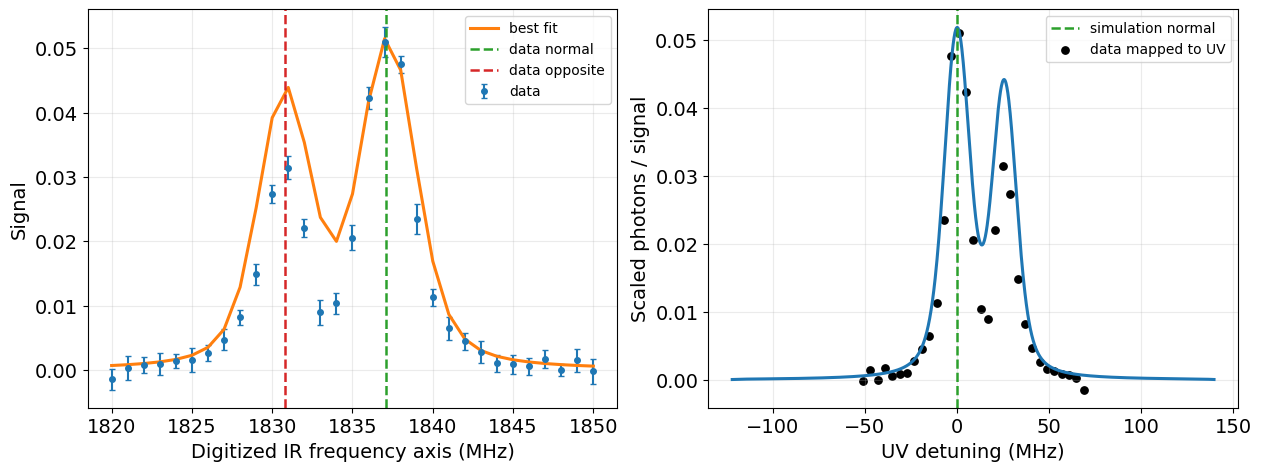

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6), constrained_layout=True)

axes[0].errorbar(x_ir_MHz, y_data, yerr=sy_data, fmt="o", ms=4, capsize=2, label="data")
axes[0].plot(x_ir_MHz, model_y, lw=2.2, label="best fit")
axes[0].axvline(data_peaks["normal_ir_MHz"], color="C2", ls="--", lw=1.8, label="data normal")
axes[0].axvline(data_peaks["opposite_ir_MHz"], color="C3", ls="--", lw=1.8, label="data opposite")
axes[0].set_xlabel("Digitized IR frequency axis (MHz)")
axes[0].set_ylabel("Signal")
axes[0].grid(alpha=0.25)
axes[0].legend(fontsize=10)

axes[1].plot(
    final_scan["detuning_MHz"], final_scan["doppler_photons"][:, 0] * best_fit["scale"], lw=2.2
)
axes[1].axvline(
    best_fit["sim_normal_delta_MHz"], color="C2", ls="--", lw=1.8, label="simulation normal"
)
axes[1].scatter(data_delta_uv, y_data, s=28, color="k", label="data mapped to UV")
axes[1].set_xlabel("UV detuning (MHz)")
axes[1].set_ylabel("Scaled photons / signal")
axes[1].grid(alpha=0.25)
axes[1].legend(fontsize=10)

## Notes

- If the compact/full validation is not close enough, set `compact=False` inside `build_fit_model` for the fit, at higher cost.
- If the best point is on a grid boundary, widen `POWER_GRID_MW` or `E_FIT_BOUNDS` and rerun the coarse fit.
- The final section intentionally recomputes only one trace at final-quality settings.
